<a href="https://colab.research.google.com/github/TungIT2912/Machine-Learning-Project-Crop-Yield-Prediction/blob/main/Crop_Yield_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌾 Crop Yield Prediction

I want to predict how much a crop will grow (in hectograms per hectare) based on rainfall, temperature, pesticide use, and crop type.

I follow the **CRISP-DM** process: Understand → Explore → Clean → Train → Evaluate.

| Detail | Value |
|--------|-------|
| **Models compared** | Linear Regression vs Random Forest |
| **Dataset** | [Kaggle — Crop Yield Prediction](https://www.kaggle.com/datasets/patelris/crop-yield-prediction-dataset) |
| **Size** | 28,242 rows × 7 columns |

### Columns in the dataset
| Column | What it means |
|--------|---------------|
| `Area` | Country (101 countries) |
| `Item` | Crop type (10 crops) |
| `Year` | Year of record (1990–2013) |
| `hg/ha_yield` | **TARGET** — how much the crop yielded |
| `average_rain_fall_mm_per_year` | Annual rainfall in mm |
| `pesticides_tonnes` | Pesticide use in tonnes |
| `avg_temp` | Average temperature in °C |

### How to run
1. Upload `yield_df.csv` when Cell 2 prompts you (it's inside the Kaggle zip)
2. Go to **Runtime → Run All**
3. Plots save to `results/`, trained models to `models/`


## Step 1 — Install Libraries

In [15]:
# Install everything I need (quietly so it doesn't flood the screen)
!pip install pandas numpy scikit-learn matplotlib seaborn joblib -q
print("✓ Libraries ready")


✓ Libraries ready


## Step 2 — Load the Dataset

Upload `yield_df.csv` from the Kaggle zip.  


In [16]:
import os, shutil
import pandas as pd
import numpy as np

# Create folders to store outputs
os.makedirs('data', exist_ok=True)
os.makedirs('results', exist_ok=True)
os.makedirs('models', exist_ok=True)

DATA_PATH = 'data/yield_df.csv'

# Check common locations where the file might already exist
for candidate in ['/content/sample_data/yield_df.csv']:
    if os.path.exists(candidate):
        shutil.copy(candidate, DATA_PATH)
        print(f"Found {candidate} — copied to {DATA_PATH}")
        break

# Load the CSV into a DataFrame
df = pd.read_csv(DATA_PATH)
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

print(f"\nDataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")
display(df.head())


Found /content/sample_data/yield_df.csv — copied to data/yield_df.csv

Dataset loaded: 28,242 rows x 7 columns
Columns: ['Area', 'Item', 'Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']


,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


## Step 3 — Understand the Data (CRISP-DM: Data Understanding)

Before doing anything else, let's look at what I have:
- How many rows/columns?
- Any missing values?

In [17]:
def show_data_summary(df):
    print("=" * 55)
    print("DATASET SUMMARY")
    print("=" * 55)
    print(f"Shape   : {df.shape[0]:,} rows x {df.shape[1]} columns")
    print(f"\nColumn types:")
    print(df.dtypes)

    print(f"\nMissing values:")
    missing = df.isnull().sum()
    has_missing = missing[missing > 0]
    print(has_missing if len(has_missing) > 0 else "  None — the dataset is complete")

    print("=" * 55)

show_data_summary(df)


DATASET SUMMARY
Shape   : 28,242 rows x 7 columns

Column types:
Area                              object
Item                              object
Year                               int64
hg/ha_yield                        int64
average_rain_fall_mm_per_year    float64
pesticides_tonnes                float64
avg_temp                         float64
dtype: object

Missing values:
  None — the dataset is complete


## Step 4 — Explore the Data with Charts (EDA)

Now I visualise the data to spot patterns, outliers, and relationships between features.

Four plots:
1. **Histograms** — how each number is distributed
2. **Correlation matrix** — which numbers move together
3. **Scatter plots** — how each feature relates to crop yield
4. **Bar charts** — average yield by crop type and by country


Saved: results/histograms.png


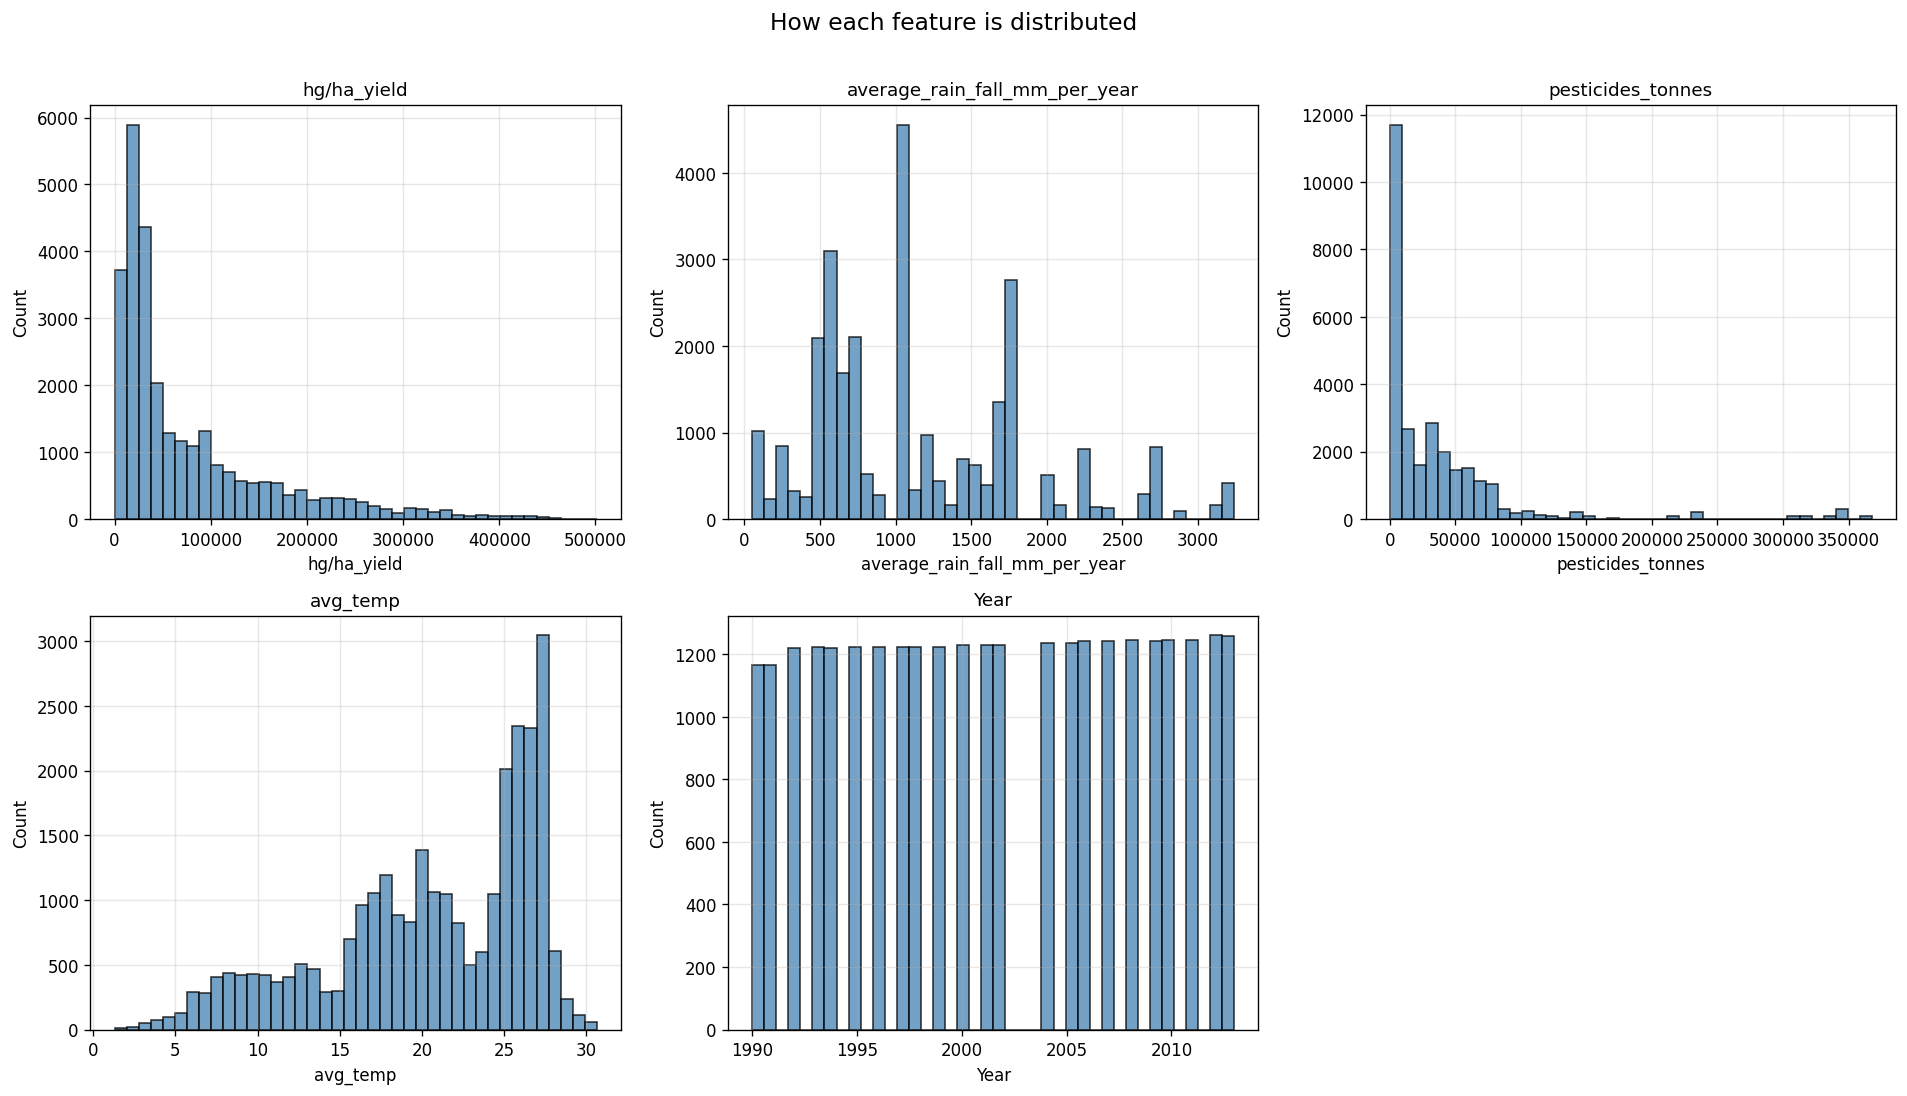

Saved: results/correlation_matrix.png


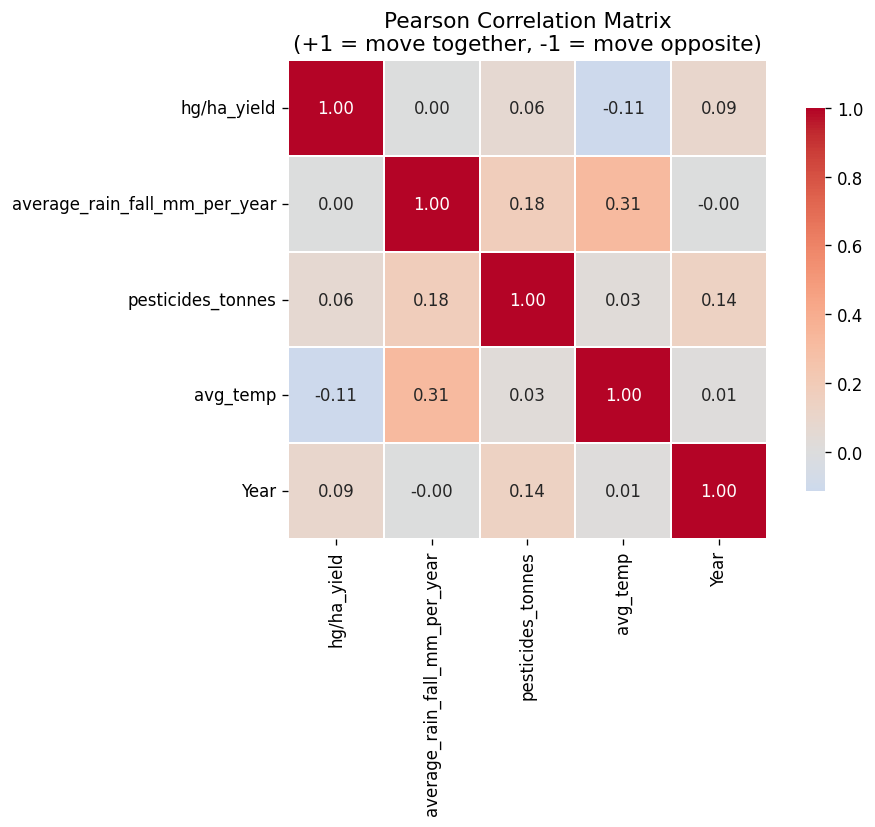

Saved: results/yield_vs_features.png


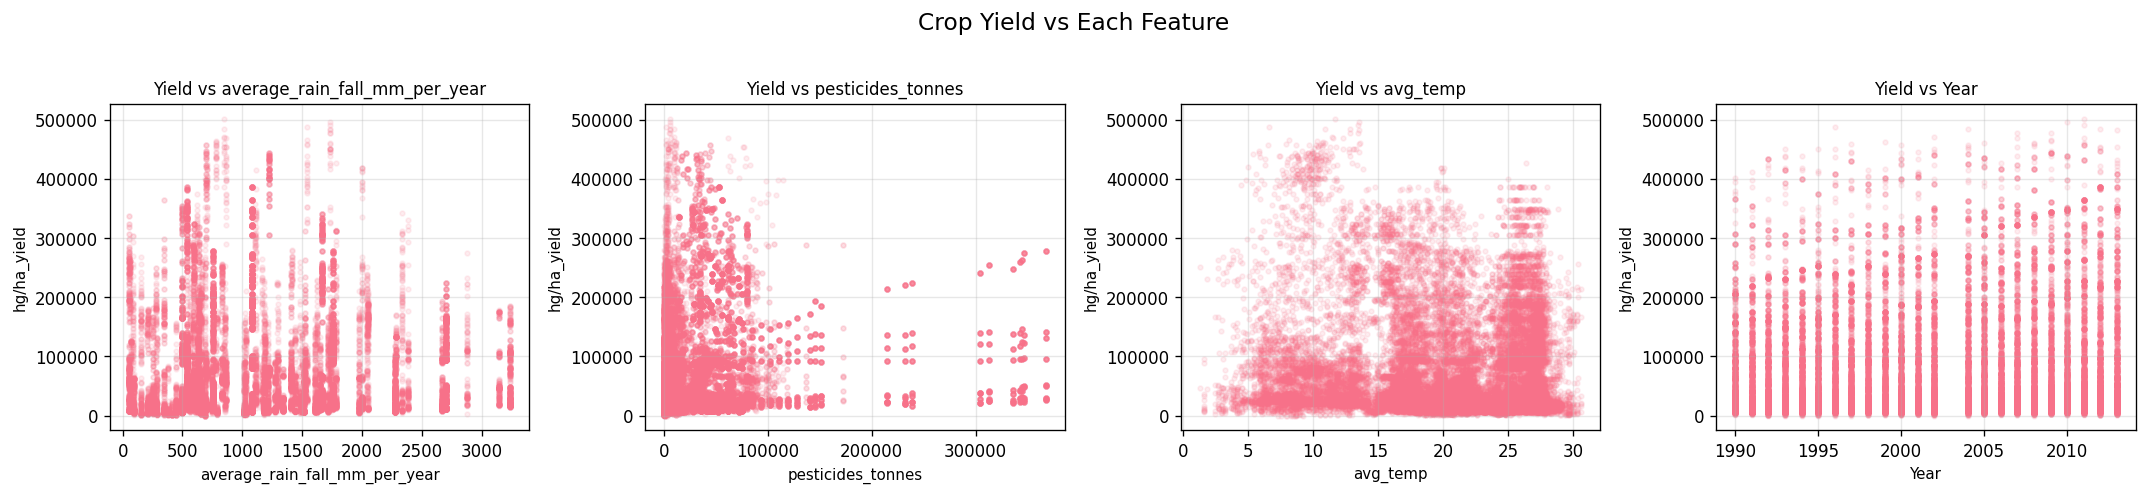

Saved: results/yield_by_category.png


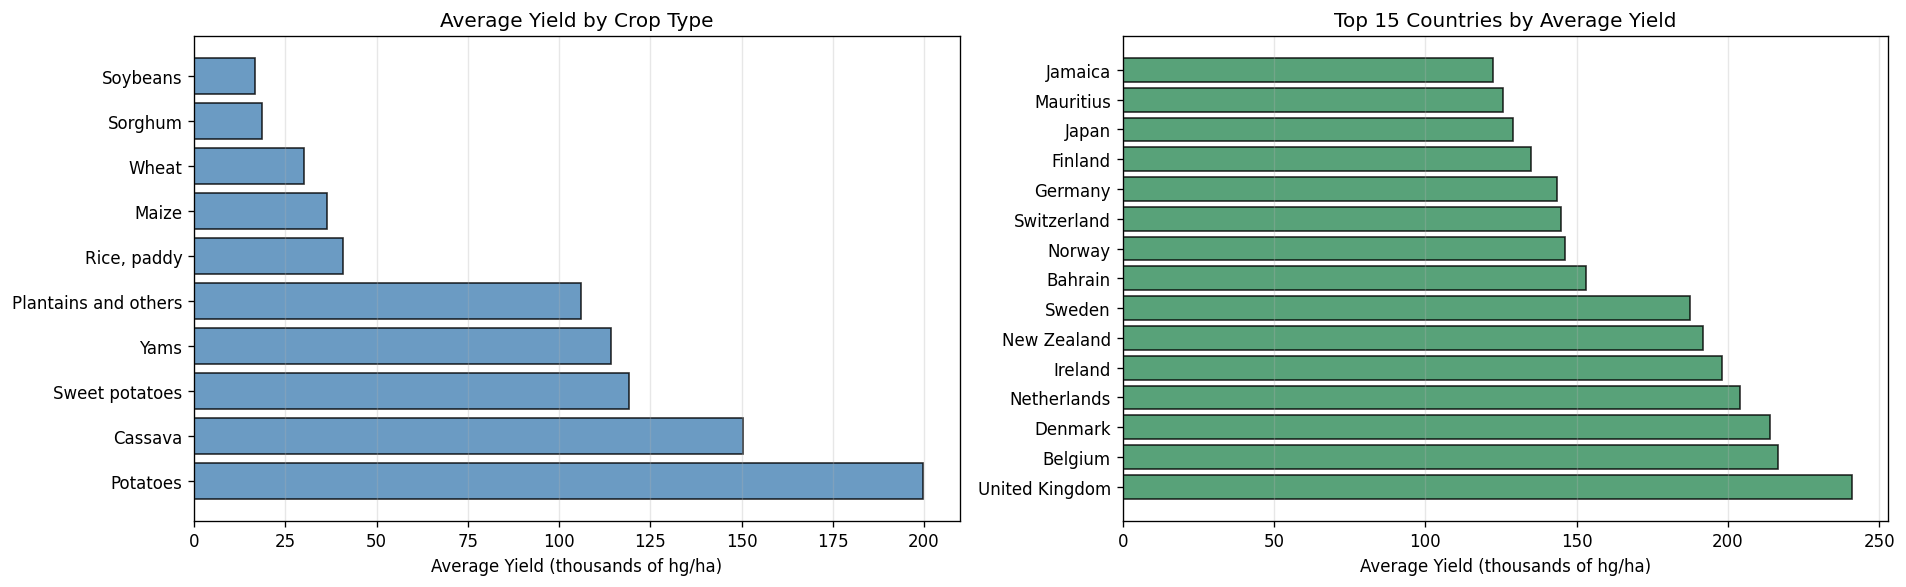

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120})
sns.set_palette('husl')

TARGET = 'hg/ha_yield'
NUM_COLS = ['hg/ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp', 'Year']
FEATURES = [c for c in NUM_COLS if c != TARGET]


def plot_histograms(df):
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    axes = axes.flatten()
    for i, col in enumerate(NUM_COLS):
        axes[i].hist(df[col].dropna(), bins=40, edgecolor='black', alpha=0.75, color='steelblue')
        axes[i].set_title(col, fontsize=11)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
        axes[i].grid(alpha=0.3)
    axes[5].set_visible(False)
    plt.suptitle('How each feature is distributed', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig('results/histograms.png', dpi=150, bbox_inches='tight')
    print("Saved: results/histograms.png")
    plt.show()


def plot_correlation(df):
    plt.figure(figsize=(9, 7))
    corr = df[NUM_COLS].corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, square=True, linewidths=1, cbar_kws={'shrink': 0.8})
    plt.title('Pearson Correlation Matrix\n(+1 = move together, -1 = move opposite)', fontsize=13)
    plt.tight_layout()
    plt.savefig('results/correlation_matrix.png', dpi=150, bbox_inches='tight')
    print("Saved: results/correlation_matrix.png")
    plt.show()


def plot_yield_vs_features(df):
    fig, axes = plt.subplots(1, len(FEATURES), figsize=(18, 4))
    for i, col in enumerate(FEATURES):
        axes[i].scatter(df[col], df[TARGET], alpha=0.12, s=8)
        axes[i].set_xlabel(col, fontsize=9)
        axes[i].set_ylabel('hg/ha_yield', fontsize=9)
        axes[i].set_title(f'Yield vs {col}', fontsize=10)
        axes[i].grid(alpha=0.3)
    plt.suptitle('Crop Yield vs Each Feature', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig('results/yield_vs_features.png', dpi=150, bbox_inches='tight')
    print("Saved: results/yield_vs_features.png")
    plt.show()


def plot_categorical_yield(df):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    crop_avg = df.groupby('Item')[TARGET].mean().sort_values(ascending=False)
    axes[0].barh(crop_avg.index, crop_avg.values / 1000,
                 color='steelblue', edgecolor='black', alpha=0.8)
    axes[0].set_xlabel('Average Yield (thousands of hg/ha)')
    axes[0].set_title('Average Yield by Crop Type')
    axes[0].grid(alpha=0.3, axis='x')
    country_avg = df.groupby('Area')[TARGET].mean().sort_values(ascending=False).head(15)
    axes[1].barh(country_avg.index, country_avg.values / 1000,
                 color='seagreen', edgecolor='black', alpha=0.8)
    axes[1].set_xlabel('Average Yield (thousands of hg/ha)')
    axes[1].set_title('Top 15 Countries by Average Yield')
    axes[1].grid(alpha=0.3, axis='x')
    plt.tight_layout()
    plt.savefig('results/yield_by_category.png', dpi=150, bbox_inches='tight')
    print("Saved: results/yield_by_category.png")
    plt.show()


plot_histograms(df)
plot_correlation(df)
plot_yield_vs_features(df)
plot_categorical_yield(df)


## Step 5 — Clean and Prepare the Data (CRISP-DM: Data Preparation)

Machine learning models only work with numbers, so I need to:
1. **Fill missing values** — numbers get the column average; text gets the most common value
2. **Encode text columns** — turn "India", "Wheat" etc. into numbers (Label Encoding)
3. **Split** — 80% for training, 20% for testing
4. **Scale features** — bring all numbers to the same range (StandardScaler)


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder




def encode_text_columns(df):
    df = df.copy()
    encoders = {}
    for col in df.select_dtypes(include='object').columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        encoders[col] = le
        print(f"  '{col}' encoded: {len(le.classes_)} categories -> integers")
    return df, encoders


def split_and_scale(X, y, test_size=0.2, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state)
    print(f"Training rows: {X_train.shape[0]:,}  |  Test rows: {X_test.shape[0]:,}")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)
    print("Features scaled (mean=0, std=1)")
    return X_train_scaled, X_test_scaled, y_train, y_test, scaler


print("=" * 50)
print("DATA PREPARATION")
print("=" * 50)

df_encoded, encoders = encode_text_columns(df)

X = df_encoded.drop(columns=[TARGET])
y = df_encoded[TARGET]
feature_names = list(X.columns)
print(f"\nFeatures used: {feature_names}")

X_train, X_test, y_train, y_test, scaler = split_and_scale(X, y)
print("\nPreparation complete")


DATA PREPARATION
  'Area' encoded: 101 categories -> integers
  'Item' encoded: 10 categories -> integers

Features used: ['Area', 'Item', 'Year', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']
Training rows: 22,593  |  Test rows: 5,649
Features scaled (mean=0, std=1)

Preparation complete


## Step 6 — Train the Models (CRISP-DM: Modelling)

I train two models and compare them:

| Model | How it works |
|-------|-------------|
| **Linear Regression** | Draws a straight line through the data — fast and simple |
| **Random Forest** | Builds 100 decision trees and averages their answers — usually more accurate |


In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import joblib

def train_linear_regression(X_train, y_train, feature_names):
    print("\n" + "=" * 50)
    print("Training: Linear Regression")
    print("=" * 50)
    model = LinearRegression()
    model.fit(X_train, y_train)
    print(f"Trained on {X_train.shape[0]:,} samples with {X_train.shape[1]} features")
    print(f"Intercept: {model.intercept_:.2f}")
    print("\nCoefficients (how much each feature shifts the prediction):")
    for feature, coef in zip(feature_names, model.coef_):
        print(f"  {feature:<40}: {coef:>10.2f}")

    return model


def train_random_forest(X_train, y_train, feature_names, n_trees=100):
    print("\n" + "=" * 50)
    print(f"Training: Random Forest ({n_trees} trees)")
    print("=" * 50)
    model = RandomForestRegressor(n_estimators=n_trees, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    print(f"Trained on {X_train.shape[0]:,} samples")
    print("\nFeature importance (higher = more useful for predictions):")
    sorted_feats = sorted(zip(feature_names, model.feature_importances_), key=lambda x: -x[1])
    for feature, importance in sorted_feats:
        bar = 'I' * int(importance * 40)
        print(f"  {feature:<40}: {importance:.4f}  {bar}")

    return model


lr_model = train_linear_regression(X_train, y_train, feature_names)
joblib.dump(lr_model, 'models/linear_regression.pkl')
print("\nSaved: models/linear_regression.pkl")

rf_model = train_random_forest(X_train, y_train, feature_names)
joblib.dump(rf_model, 'models/random_forest.pkl')
print("\nSaved: models/random_forest.pkl")



Training: Linear Regression
Trained on 22,593 samples with 6 features
Intercept: 77051.20

Coefficients (how much each feature shifts the prediction):
  Area                                    :    2432.67
  Item                                    :  -20281.26
  Year                                    :    7195.78
  average_rain_fall_mm_per_year           :    2390.50
  pesticides_tonnes                       :    6036.16
  avg_temp                                :  -11967.76

Saved: models/linear_regression.pkl

Training: Random Forest (100 trees)
Trained on 22,593 samples

Feature importance (higher = more useful for predictions):
  Item                                    : 0.6087  IIIIIIIIIIIIIIIIIIIIIIII
  pesticides_tonnes                       : 0.1103  IIII
  avg_temp                                : 0.1085  IIII
  average_rain_fall_mm_per_year           : 0.0865  III
  Area                                    : 0.0550  II
  Year                                    : 0.0310  I

S

## Step 7 — Evaluate the Models (CRISP-DM: Evaluation)

I measure four things:

| Metric | What it tells us |
|--------|-----------------|
| **RMSE** | Typical prediction error (same units as yield) — lower is better |
| **MAE** | Average absolute error — easier to interpret than RMSE |
| **R²** | How much of the variation our model explains (1.0 = perfect) |
| **MAPE** | Error as a percentage of the true value — lower is better |


In [21]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np
import pandas as pd

def compute_metrics(y_true, y_pred):
    y_true = np.array(y_true)
    return {
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred),
        'MAPE (%)': np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1, y_true))) * 100
    }

def evaluate_models(models, X_test, y_test):
    y_true = np.array(y_test)
    results = {}

    print("\n" + "="*50)
    print("MODEL EVALUATION")
    print("="*50)

    for name, model in models.items():
        y_pred = model.predict(X_test)
        metrics = compute_metrics(y_true, y_pred)
        results[name] = metrics

        print(f"\n{name}:")
        for k, v in metrics.items():
            print(f"  {k:<12}: {v:,.4f}")

    results_df = pd.DataFrame(results).T
    return results_df

models_to_compare = {
    'Linear Regression': lr_model,
    'Random Forest': rf_model
}

results_df = evaluate_models(models_to_compare, X_test, y_test)
print("\nSummary Table:")
print(results_df)




MODEL EVALUATION

Linear Regression:
  RMSE        : 81,501.7645
  MAE         : 62,444.3106
  R2          : 0.0843
  MAPE (%)    : 231.0577

Random Forest:
  RMSE        : 10,177.9741
  MAE         : 3,753.4584
  R2          : 0.9857
  MAPE (%)    : 7.7168

Summary Table:
                           RMSE           MAE        R2    MAPE (%)
Linear Regression  81501.764465  62444.310630  0.084252  231.057738
Random Forest      10177.974105   3753.458386  0.985719    7.716778


## Step 8 — Results and Summary

Everything is done! This final cell prints the winner, key numbers.


In [22]:
print("=" * 60)
print("FINAL RESULTS")
print("=" * 60)
best = results_df['R2'].idxmax()
print(f"\nBest model : {best}")
print(f"   R2       : {results_df.loc[best, 'R2']:.4f}  (closer to 1.0 = better)")
print(f"   RMSE     : {results_df.loc[best, 'RMSE']:,.0f} hg/ha")
print(f"   MAE      : {results_df.loc[best, 'MAE']:,.0f} hg/ha")
print(f"   MAPE     : {results_df.loc[best, 'MAPE (%)']:.2f}%")

print("\nKey finding:")
print("  Crop type (Item) is by far the most important feature.")
print("  RF importances: Item ~0.61, pesticides ~0.11, temp ~0.11, rainfall ~0.09")


print("\nPipeline complete!")


FINAL RESULTS

Best model : Random Forest
   R2       : 0.9857  (closer to 1.0 = better)
   RMSE     : 10,178 hg/ha
   MAE      : 3,753 hg/ha
   MAPE     : 7.72%

Key finding:
  Crop type (Item) is by far the most important feature.
  RF importances: Item ~0.61, pesticides ~0.11, temp ~0.11, rainfall ~0.09

Pipeline complete!
